# Calculate quantum yield

This notebook calculates $\Phi = n_\mathrm{reactive}/n_\mathrm{total}$. A trajectory is reactive only when its cis/trans label changes between the first and final XYZ frame **and** its final MCH state is ground state 1. Final-excited trajectories are excluded from both counts.

(Ethene has no chemically meaningful cis/trans isomerism. The current results are a workflow test using a chosen H–C–C–H torsion.)

In [31]:
from pathlib import Path

# Run from either the repository root or sharc/.
SEARCH_ROOT = Path("sharc") if Path("sharc").is_dir() else Path(".")
TRAJ_GLOB = "structure_0006/traj-allmols/**/TRAJ_*"

# 1-based C-N=N-C atom indices for azobenzene.
DIHEDRAL_ATOMS = (4, 5, 6, 7)
CIS_TRANS_THRESHOLD_DEG = 90.0
GROUND_MCH_STATE = 1
NN_BOND_MIN_ANGSTROM = 0.9
NN_BOND_EXCLUSION_ANGSTROM = 3.0

print(f"Searching: {SEARCH_ROOT.resolve()}")
print(f"Dihedral atoms: {DIHEDRAL_ATOMS}; ground MCH state: {GROUND_MCH_STATE}")

Searching: /home/lim_yt/X-MACE-sampling/sharc
Dihedral atoms: (4, 5, 6, 7); ground MCH state: 1


In [48]:
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def parse_xyz_lines(lines, source):
    """Return all conventional XYZ frames as (symbols, coordinates)."""
    frames, pos = [], 0
    while pos < len(lines):
        while pos < len(lines) and not lines[pos].strip():
            pos += 1
        if pos == len(lines):
            break
        try:
            natoms = int(lines[pos].strip())
        except ValueError as error:
            raise ValueError(f"{source}: expected atom count at line {pos + 1}") from error
        if natoms <= 0 or pos + natoms + 1 >= len(lines):
            raise ValueError(f"{source}: incomplete or invalid XYZ frame")
        symbols, xyz = [], []
        for line_number, line in enumerate(lines[pos + 2 : pos + 2 + natoms], pos + 3):
            fields = line.split()
            if len(fields) < 4:
                raise ValueError(f"{source}: malformed atom record at line {line_number}")
            try:
                xyz.append([float(value) for value in fields[1:4]])
            except ValueError as error:
                raise ValueError(f"{source}: non-numeric coordinate at line {line_number}") from error
            symbols.append(fields[0])
        frames.append((symbols, np.asarray(xyz, dtype=float)))
        pos += natoms + 2
    if not frames:
        raise ValueError(f"{source}: no XYZ frames")
    return frames


def signed_dihedral_deg(coordinates, atom_indices):
    indices = np.asarray(atom_indices, dtype=int) - 1
    if len(indices) != 4 or np.any(indices < 0) or np.any(indices >= len(coordinates)):
        raise ValueError(f"invalid atom indices {tuple(atom_indices)} for {len(coordinates)} atoms")
    p0, p1, p2, p3 = coordinates[indices]
    b0, b1, b2 = -(p1 - p0), p2 - p1, p3 - p2
    b1_norm = np.linalg.norm(b1)
    if b1_norm == 0:
        raise ValueError("middle dihedral bond has zero length")
    b1 /= b1_norm
    v, w = b0 - np.dot(b0, b1) * b1, b2 - np.dot(b2, b1) * b1
    if np.linalg.norm(v) == 0 or np.linalg.norm(w) == 0:
        raise ValueError("dihedral is undefined for collinear atoms")
    angle = math.degrees(math.atan2(np.dot(np.cross(b1, v), w), np.dot(v, w)))
    return ((angle + 180.0) % 360.0) - 180.0


def bond_length_angstrom(coordinates, atom_indices):
    """Return a 1-based atom-pair distance in Å."""
    indices = np.asarray(atom_indices, dtype=int) - 1
    if len(indices) != 2 or np.any(indices < 0) or np.any(indices >= len(coordinates)):
        raise ValueError(f"invalid atom indices {tuple(atom_indices)} for {len(coordinates)} atoms")
    return float(np.linalg.norm(coordinates[indices[0]] - coordinates[indices[1]]))


def frame_times_fs(lines, source):
    """Extract the SHARC time (fs) from each XYZ frame comment."""
    times, pos = [], 0
    while pos < len(lines):
        while pos < len(lines) and not lines[pos].strip():
            pos += 1
        if pos == len(lines):
            break
        try:
            natoms = int(lines[pos].strip())
        except ValueError as error:
            raise ValueError(f"{source}: expected atom count at line {pos + 1}") from error
        if pos + natoms + 1 >= len(lines):
            raise ValueError(f"{source}: incomplete or invalid XYZ frame")
        match = re.search(r"\bt=\s*([-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?)", lines[pos + 1])
        if not match:
            raise ValueError(f"{source}: missing time in frame comment at line {pos + 2}")
        times.append(float(match.group(1)))
        pos += natoms + 2
    return np.asarray(times, dtype=float)


def classify_dihedral(angle):
    return "cis" if abs(angle) <= CIS_TRANS_THRESHOLD_DEG else "trans"


def final_mch_state(lis_path):
    """Read the final SHARC output.lis data row: Step Time diag_state MCH_state ..."""
    rows = [line.split() for line in lis_path.read_text(encoding="utf-8").splitlines()
            if line.strip() and not line.lstrip().startswith("#")]
    if not rows or len(rows[-1]) < 4:
        raise ValueError(f"{lis_path}: no valid output.lis data row")
    try:
        return int(rows[-1][3])
    except ValueError as error:
        raise ValueError(f"{lis_path}: invalid final MCH state") from error


def mch_states(lis_path):
    """Read the MCH state for every SHARC output.lis time step."""
    rows = [line.split() for line in lis_path.read_text(encoding="utf-8").splitlines()
            if line.strip() and not line.lstrip().startswith("#")]
    if not rows or any(len(row) < 4 for row in rows):
        raise ValueError(f"{lis_path}: no valid output.lis data rows")
    try:
        return np.asarray([int(row[3]) for row in rows], dtype=int)
    except ValueError as error:
        raise ValueError(f"{lis_path}: invalid MCH state") from error


def outcome(initial, final, final_state):
    if final_state != GROUND_MCH_STATE:
        return "excluded_final_excited"
    return "reactive" if initial != final else "nonreactive"


def metadata(path):
    parts = path.parts
    pick = lambda prefix: next((part for part in parts if part.startswith(prefix)), "unknown")
    return pick("structure_"), pick("Singlet_"), pick("TRAJ_")

In [33]:
# In-notebook tests: parser, reactive directions, nonreactive, and excited-state exclusion.
xyz_fixture = """4
first
H 1 0 0
C 0 0 0
C 0 1 0
H 1 1 0
4
last
H 1 0 0
C 0 0 0
C 0 1 0
H -1 1 0
"""
frames = parse_xyz_lines(xyz_fixture.splitlines(), "fixture")
cis = classify_dihedral(signed_dihedral_deg(frames[0][1], (1, 2, 3, 4)))
trans = classify_dihedral(signed_dihedral_deg(frames[1][1], (1, 2, 3, 4)))
assert (cis, trans) == ("cis", "trans")
assert outcome(cis, trans, 1) == "reactive"
assert outcome(trans, cis, 1) == "reactive"
assert outcome(cis, cis, 1) == "nonreactive"
assert outcome(cis, trans, 2) == "excluded_final_excited"
print("Self-check passed.")

Self-check passed.


In [34]:
records = []
trajectory_dirs = sorted(path for path in SEARCH_ROOT.glob(TRAJ_GLOB) if path.is_dir())
if not trajectory_dirs:
    warnings.warn(f"No trajectory folders found under {SEARCH_ROOT}/{TRAJ_GLOB}")

for trajectory_dir in trajectory_dirs:
    xyz_path, lis_path = trajectory_dir / "output.xyz", trajectory_dir / "output.lis"
    structure, singlet, trajectory = metadata(trajectory_dir)
    record = {"structure": structure, "singlet": singlet, "trajectory": trajectory,
              "initial_dihedral_deg": np.nan, "initial_label": None,
              "final_dihedral_deg": np.nan, "final_label": None,
              "min_nn_bond_length_angstrom": np.nan,
              "max_nn_bond_length_angstrom": np.nan,
              "final_mch_state": pd.NA, "outcome": "skipped_invalid_output",
              "output_xyz": str(xyz_path), "reason": None}
    try:
        if not xyz_path.is_file() or xyz_path.stat().st_size == 0:
            raise ValueError("missing or empty output.xyz")
        if not lis_path.is_file() or lis_path.stat().st_size == 0:
            raise ValueError("missing or empty output.lis")
        frames = parse_xyz_lines(xyz_path.read_text(encoding="utf-8").splitlines(), str(xyz_path))
        nn_bond_lengths = [bond_length_angstrom(coordinates, DIHEDRAL_ATOMS[1:3]) for _, coordinates in frames]
        min_nn_bond_length = min(nn_bond_lengths)
        max_nn_bond_length = max(nn_bond_lengths)
        initial_angle = signed_dihedral_deg(frames[0][1], DIHEDRAL_ATOMS)
        final_angle = signed_dihedral_deg(frames[-1][1], DIHEDRAL_ATOMS)
        final_state = final_mch_state(lis_path)
        record.update({"initial_dihedral_deg": initial_angle, "initial_label": classify_dihedral(initial_angle),
                       "final_dihedral_deg": final_angle, "final_label": classify_dihedral(final_angle),
                       "min_nn_bond_length_angstrom": min_nn_bond_length,
                       "max_nn_bond_length_angstrom": max_nn_bond_length, "final_mch_state": final_state})
        if min_nn_bond_length < NN_BOND_MIN_ANGSTROM or max_nn_bond_length > NN_BOND_EXCLUSION_ANGSTROM:
            record["outcome"] = "excluded_nn_bond_length"
        else:
            record["outcome"] = outcome(record["initial_label"], record["final_label"], final_state)
    except (OSError, UnicodeDecodeError, ValueError) as error:
        record["reason"] = str(error)
        warnings.warn(f"Skipped {trajectory_dir}: {error}")
    records.append(record)

results = pd.DataFrame(records)
for column in ("initial_dihedral_deg", "final_dihedral_deg"):
    if column in results:
        results[column] = results[column].round(3)
results

,structure,singlet,trajectory,initial_dihedral_deg,initial_label,final_dihedral_deg,final_label,min_nn_bond_length_angstrom,max_nn_bond_length_angstrom,final_mch_state,outcome,output_xyz,reason
0,structure_0006,Singlet_1,TRAJ_00001,173.213,trans,151.032,trans,1.264827,1.550475,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
1,structure_0006,Singlet_1,TRAJ_00002,173.453,trans,177.190,trans,1.067240,1.535227,1,nonreactive,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
2,structure_0006,Singlet_1,TRAJ_00003,172.012,trans,171.061,trans,1.288529,1.500393,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
3,structure_0006,Singlet_1,TRAJ_00004,169.124,trans,164.667,trans,1.221838,1.565316,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
4,structure_0006,Singlet_1,TRAJ_00005,167.627,trans,178.952,trans,1.253021,1.533092,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,structure_0006,Singlet_1,TRAJ_00096,-171.570,trans,-177.485,trans,1.267475,1.551494,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
96,structure_0006,Singlet_1,TRAJ_00097,-169.612,trans,-28.059,cis,0.565581,39915.100176,1,excluded_nn_bond_length,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
97,structure_0006,Singlet_1,TRAJ_00098,-170.529,trans,177.446,trans,1.243930,1.543093,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None
98,structure_0006,Singlet_1,TRAJ_00099,-173.994,trans,-158.385,trans,1.183617,1.554758,2,excluded_final_excited,structure_0006/traj-allmols/Singlet_1/TRAJ_000...,None


In [44]:
eligible = results[results["outcome"].isin(["reactive", "nonreactive"])]
n_reactive = int((results["outcome"] == "reactive").sum())
n_total = len(eligible)  # valid trajectories ending in the ground MCH state
n_excluded_excited = int((results["outcome"] == "excluded_final_excited").sum())
n_excluded_nn_bond_length = int((results["outcome"] == "excluded_nn_bond_length").sum())
n_nonreactive = int((results["outcome"] == "nonreactive").sum())
quantum_yield = n_reactive / n_total if n_total else np.nan

summary = pd.DataFrame([{
    "n_reactive": n_reactive,
    "n_total_ground_state": n_total,
    "n_nonreactive": n_nonreactive,
    "n_excluded_final_excited": n_excluded_excited,
    "n_excluded_nn_bond_length": n_excluded_nn_bond_length,
    "n_skipped_invalid_output": int((results["outcome"] == "skipped_invalid_output").sum()),
    "quantum_yield": quantum_yield,
}])
display(summary)
if n_total == 0:
    print("Quantum yield is undefined since no trajectory ended in MCH ground state 1.")
else:
    print(f"Quantum yield = {quantum_yield:.4f} ({n_reactive}/{n_total})")

,n_reactive,n_total_ground_state,n_nonreactive,n_excluded_final_excited,n_excluded_nn_bond_length,n_skipped_invalid_output,quantum_yield
0,5,29,24,68,3,0,0.172414


Quantum yield = 0.1724 (5/29)


In [43]:
# Tables of trajectories retained in the quantum-yield calculation.
report_columns = [
    "trajectory", "initial_dihedral_deg", "final_dihedral_deg",
    "min_nn_bond_length_angstrom", "max_nn_bond_length_angstrom", "final_mch_state",
]

def outcome_table(outcome_name):
    table = results.loc[results["outcome"] == outcome_name, report_columns].copy()
    table.insert(0, "trajectory_index", table.pop("trajectory").str.removeprefix("TRAJ_").astype(int))
    return table.sort_values("trajectory_index").reset_index(drop=True).round(5)

reactive_trajectories = outcome_table("reactive")
nonreactive_trajectories = outcome_table("nonreactive")

print("Reactive trajectories")
display(reactive_trajectories)
print("Nonreactive trajectories")
display(nonreactive_trajectories)

Reactive trajectories


,trajectory_index,initial_dihedral_deg,final_dihedral_deg,min_nn_bond_length_angstrom,max_nn_bond_length_angstrom,final_mch_state
0,10,179.661,-2.376,1.13048,1.57250,1
1,12,177.758,-36.601,1.16283,1.52853,1
2,26,-178.067,-15.498,1.12857,1.56373,1
3,50,172.820,-7.008,1.15845,1.36682,1
4,72,-176.847,22.001,1.11814,1.48646,1


Nonreactive trajectories


,trajectory_index,initial_dihedral_deg,final_dihedral_deg,min_nn_bond_length_angstrom,max_nn_bond_length_angstrom,final_mch_state
0,2,173.453,177.190,1.06724,1.53523,1
1,8,-178.861,-176.015,1.13629,1.57756,1
2,9,-179.211,-168.267,1.11705,1.59157,1
3,15,178.953,-174.368,1.15479,1.52990,1
4,17,176.789,-177.834,1.17680,1.55271,1
5,25,-177.864,-173.359,1.08276,1.54937,1
6,29,176.722,-174.739,1.09961,1.49823,1
7,33,-173.690,166.579,1.13569,1.54892,1
8,38,-179.810,-174.208,1.12182,1.52967,1
9,40,175.046,-174.169,1.12270,1.54012,1


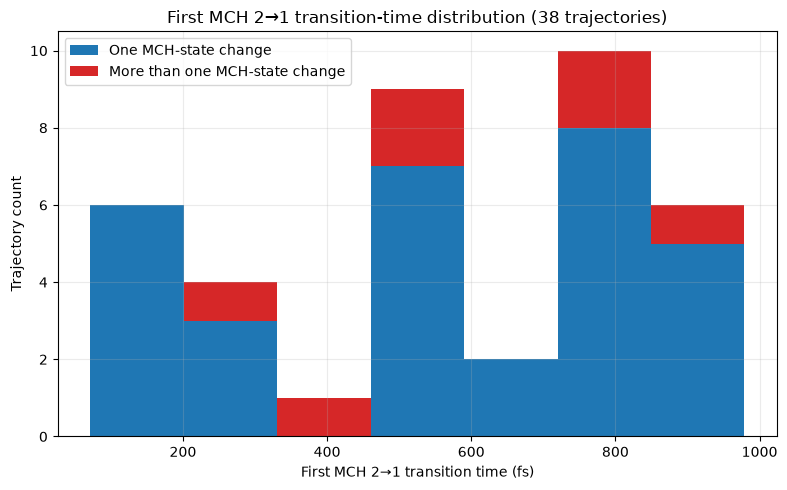

Trajectories with more than one MCH-state change: 7


,trajectory_index,first_mch_2_to_1_time_fs,n_mch_state_changes
6,7,435.0,2
10,11,565.0,4
26,27,784.0,2
41,42,940.5,2
46,47,754.0,2
69,70,552.5,2
96,97,289.0,3


In [57]:
# First MCH 2→1 transition time for every trajectory.
transition_records = []
for trajectory_dir in trajectory_dirs:
    lis_path = trajectory_dir / "output.lis"
    rows = [line.split() for line in lis_path.read_text(encoding="utf-8").splitlines()
            if line.strip() and not line.lstrip().startswith("#")]
    times_fs = np.asarray([float(row[1]) for row in rows])
    states = np.asarray([int(row[3]) for row in rows])
    change_indices = np.flatnonzero(states[1:] != states[:-1]) + 1
    fall_indices = change_indices[(states[change_indices - 1] == 2) & (states[change_indices] == 1)]
    transition_records.append({
        "trajectory_index": int(trajectory_dir.name.removeprefix("TRAJ_")),
        "first_mch_2_to_1_time_fs": times_fs[fall_indices[0]] if len(fall_indices) else np.nan,
        "n_mch_state_changes": len(change_indices),
    })

transition_summary = pd.DataFrame(transition_records).sort_values("trajectory_index").reset_index(drop=True)
first_falls = transition_summary.dropna(subset=["first_mch_2_to_1_time_fs"]).copy()
multiple_changes = first_falls[first_falls["n_mch_state_changes"] > 1]

fig, ax = plt.subplots(figsize=(8, 5))
single_change = first_falls[first_falls["n_mch_state_changes"] == 1]
bins = np.histogram_bin_edges(first_falls["first_mch_2_to_1_time_fs"], bins="auto")
ax.hist([single_change["first_mch_2_to_1_time_fs"], multiple_changes["first_mch_2_to_1_time_fs"]],
        bins=bins, stacked=True, color=["tab:blue", "tab:red"],
        label=["One MCH-state change", "More than one MCH-state change"])
ax.set(xlabel="First MCH 2→1 transition time (fs)", ylabel="Trajectory count")
ax.set_title(f"First MCH 2→1 transition-time distribution ({len(first_falls)} trajectories)")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print(f"Trajectories with more than one MCH-state change: {len(multiple_changes)}")
display(multiple_changes)